ML OBLIG1

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os; os.makedirs("figures", exist_ok=True)

df = pd.read_csv("train.csv")
print(df.shape)
print(df.isna().sum().sum())

(21263, 82)
0


Q1.1.1


In [6]:
stats = df.describe().T
stats["cv"] = stats["std"] / stats["mean"]

cols = ["mean", "std", "min", "max", "cv"]
print(stats.sort_values("std", ascending=False).head(10)[cols])
print(stats.drop("critical_temp").sort_values("cv", ascending=False).head(10)[cols])

                          mean          std       min           max        cv
range_Density      8665.438818  4097.126831  0.000000  22588.571000  0.472812
wtd_gmean_Density  3117.241110  3975.122587  0.686245  22590.000000  1.275205
gmean_Density      3460.692235  3703.256370  1.429000  22590.000000  1.070091
wtd_mean_Density   5267.188547  3221.314506  1.429000  22590.000000  0.611581
mean_Density       6111.465214  2846.785185  1.429000  22590.000000  0.465811
wtd_range_Density  2902.736814  2398.471020  0.000000  22434.160000  0.826279
std_Density        3416.910784  1673.624915  0.000000  10724.374500  0.489806
wtd_std_Density    3319.170628  1611.799629  0.000000  10410.932005  0.485603
range_fie           572.222612   309.614442  0.000000   1304.500000  0.541073
wtd_range_fie       483.517264   224.042874  0.000000   1251.855072  0.463361
                                      mean          std       min  \
wtd_gmean_ThermalConductivity    27.308061    40.191150  0.022952   
wtd_

Q 1.1.2

skew raw:   0.8602232926106779
skew log:   -1.0042645868572804
skew log1p: -0.3173279075241499


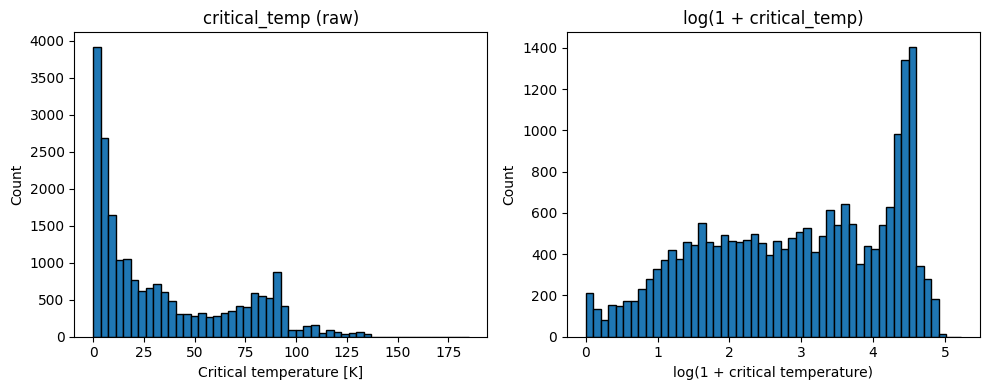

In [7]:
y = df["critical_temp"]
y_log = np.log1p(y)                  # log(1 + y)

print("skew raw:  ", y.skew())
print("skew log:  ", np.log(y).skew())
print("skew log1p:", y_log.skew())

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].hist(y, bins=50, edgecolor="black")
axes[0].set(title="critical_temp (raw)", xlabel="Critical temperature [K]", ylabel="Count")
axes[1].hist(y_log, bins=50, edgecolor="black")
axes[1].set(title="log(1 + critical_temp)", xlabel="log(1 + critical temperature)", ylabel="Count")
plt.tight_layout()
plt.savefig("figures/q112_target_distribution.pdf", bbox_inches="tight")
plt.show()